# Some important (high-level) considerations

In applying any machine learning algorithms to a dataset, several considerations are crucial.  This supplementary document covers some of the basic steps in making choices that matter to your problem.



## Learning algorithms

### Supervised learning
To model relationships and dependencies between input and output.

**Regression**

For example, can we predict the mass of a penguin given its other characteristics?

In [1]:
import seaborn as sns
import pandas as pd
sns.set_palette('bright')

penguins = sns.load_dataset('penguins')
penguins = penguins[~penguins.isna().any(axis='columns')]
penguins = penguins.sort_values('flipper_length_mm')

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

X = penguins[['flipper_length_mm']]
y = penguins['body_mass_g']

# Linear Regression
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)
print(f"Linear Regression RMSE: {root_mean_squared_error(y, y_pred_lr)}")

# Nearest Neighbors
knn = KNeighborsRegressor()
knn.fit(X, y)
y_pred_knn = knn.predict(X)
print(f"Nearest Neighbors RMSE: {root_mean_squared_error(y, y_pred_knn)}")

# Random Forest
rf = RandomForestRegressor()
rf.fit(X, y)
y_pred_rf = rf.predict(X)
print(f"Random Forest RMSE: {root_mean_squared_error(y, y_pred_rf)}")

Linear Regression RMSE: 392.1602706380618
Nearest Neighbors RMSE: 368.4116952231256
Random Forest RMSE: 345.52944155130456


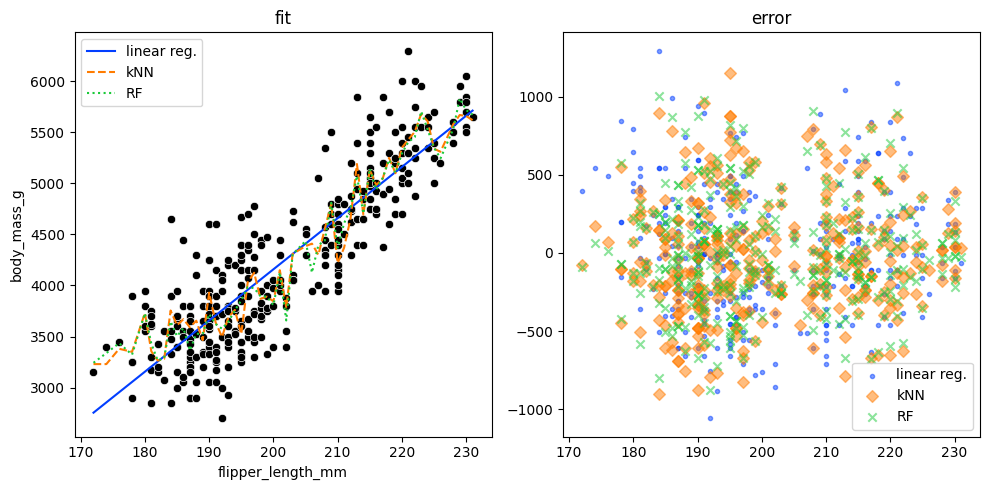

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(y='body_mass_g', x='flipper_length_mm', color='k', data=penguins, ax=ax[0])

y_preds = [y_pred_lr, y_pred_knn, y_pred_rf]
labels = ['linear reg.', 'kNN', 'RF']
linestyles = ['-', '--', ':']
markerstyles = ['.', 'D', 'x']

for j, y_pred in enumerate(y_preds):
    ax[0].plot(X, y_pred, label=labels[j], linestyle=linestyles[j])
    ax[1].scatter(X, y - y_pred, label=labels[j], marker=markerstyles[j], alpha=0.5)
ax[0].set_title('fit')
ax[1].set_title('error')
ax[0].legend()
ax[1].legend()
plt.tight_layout()

**Classification**

For example, can we predict where a penguin lives given its other characteristics?

In [5]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Define inputs and outputs
penguins = penguins.sample(frac=1)
X = penguins.drop("island", axis=1)
y = penguins["island"]

# Encode categorical variables
enc = LabelEncoder()
y = enc.fit_transform(y)
X = pd.get_dummies(X)

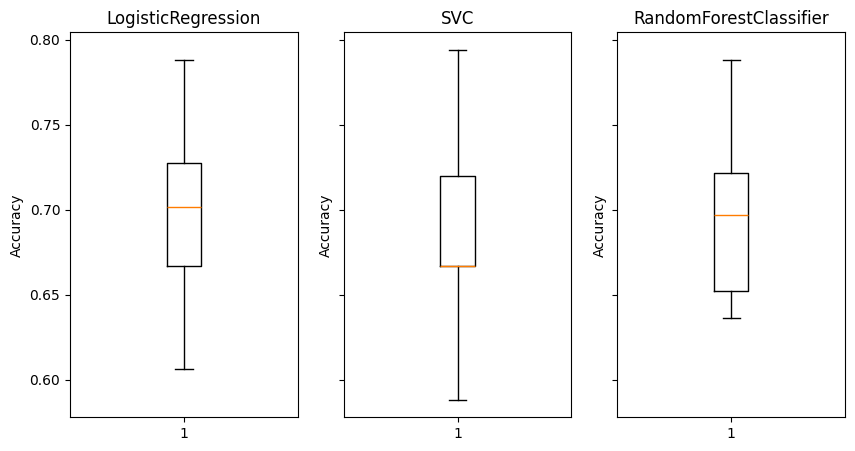

In [7]:
models = [LogisticRegression, SVC, RandomForestClassifier]

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
for j, model in enumerate(models):
    m = model()
    cvs = cross_val_score(m, X, y, cv=10)
    ax[j].boxplot(cvs)
    ax[j].set_title(type(m).__name__)
    ax[j].set_ylabel('Accuracy')

### Unsupervised learning
To identify structure or relationships.

**Clustering**

For example, can we group the penguins to identify the species using their characteristics?

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

In [9]:
# Define input and output
X = penguins.drop(["species", "island", 'sex'], axis=1)
y = penguins["species"]

# Encode categorical variables
enc = LabelEncoder()
y = enc.fit_transform(y)

In [10]:
m = KMeans()
m.fit(X)
y_pred = m.predict(X)
penguins['species_pred'] = y_pred

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

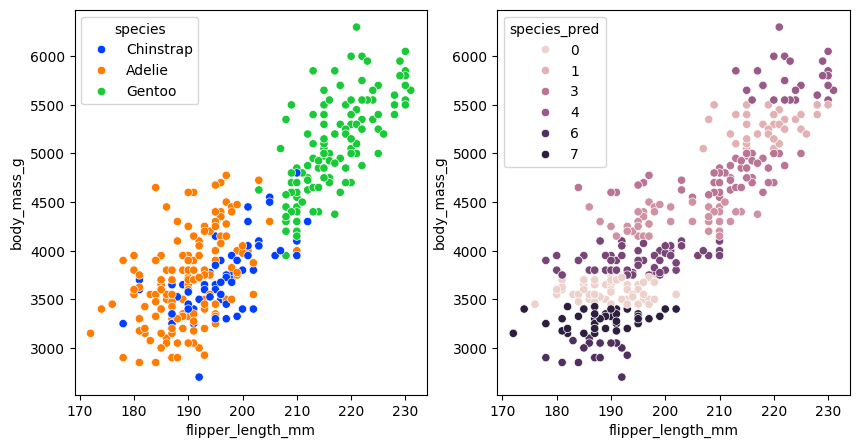

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.scatterplot(y='body_mass_g', x='flipper_length_mm', hue='species', data=penguins, ax=ax[0])
sns.scatterplot(y='body_mass_g', x='flipper_length_mm', hue='species_pred', data=penguins, ax=ax[1])

### Semi-supervised learning
Some outputs are "labeled", most are not, typically in classification problems.

```{figure} ../img/ex-semi-supervised.png
---
width: 80%
name: ex-semi-supervised
---
Example of a semi-supervised learning model {cite:p}`berthelot2019mixmatch`.
```

### Reinforcement learning
The algorithm learns by acting and observing reward.  The goal is to identify an "optimal" policy.

```{figure} ../img/reinforcement-learning.png
---
width: 70%
name: reinforcement
---
Generic modeling of a reinforcement learning model.
```